In [1]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('dirty_cafe_sales.csv')
df.head(5)
df.tail(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [6]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [7]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


Transaction ID
Transaction ID
TXN_9226047    1
TXN_8567525    1
TXN_4583012    1
TXN_6796890    1
TXN_9933628    1
TXN_4302199    1
TXN_5548914    1
TXN_3528020    1
TXN_9668108    1
TXN_8076061    1
Name: count, dtype: int64

Item
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64

Quantity
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
Name: count, dtype: int64

Price Per Unit
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64

Total Spent
Total Spent
6.0     979
12.0    939
3.0     930
4.0     923
20.0    746
15.0    734
8.0     677
10.0    524
2.0     497
9.0     479
Name: count, dtype: int64

Payment Method
Payment Method
Digital Wallet    2291

In [8]:
df.replace(["ERROR", "UNKNOWN"], np.nan, inplace=True)

In [9]:
df.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [10]:
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [11]:
df["Item"] = df["Item"].fillna(df["Item"].mode()[0])

df["Payment Method"] = df["Payment Method"].fillna(
    df["Payment Method"].mode()[0]
)

df["Location"] = df["Location"].fillna(
    df["Location"].mode()[0]
)

In [12]:
df.isnull().sum()

Transaction ID        0
Item                  0
Quantity            479
Price Per Unit      533
Total Spent         502
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

In [13]:
df[["Quantity", "Price Per Unit", "Total Spent"]].dtypes

Quantity          object
Price Per Unit    object
Total Spent       object
dtype: object

In [14]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

In [15]:
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Price Per Unit"].median()
)

df["Total Spent"] = df["Total Spent"].fillna(
    df["Total Spent"].median()
)

In [16]:
df.isnull().sum()

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

In [17]:
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

In [18]:
df["Transaction Date"] = df["Transaction Date"].fillna(
    df["Transaction Date"].mode()[0]
)

In [19]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [20]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [21]:
df["Day_of_Week"] = df["Transaction Date"].dt.day_name()

df["Month"] = df["Transaction Date"].dt.month_name()

df["Year"] = df["Transaction Date"].dt.year

In [22]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day_of_Week,Month,Year
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday,September,2023
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,Tuesday,May,2023
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19,Wednesday,July,2023
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27,Thursday,April,2023
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,Sunday,June,2023


In [23]:
df.to_csv("cleaned_cafe_sales.csv", index=False)

In [24]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date,Year
count,10000.000000,10000.00000,10000.00000,10000,10000.0
mean,3.027100,2.95265,8.87795,2023-06-25 05:52:13.440000,2023.0
min,1.000000,1.00000,1.00000,2023-01-01 00:00:00,2023.0
25%,2.000000,2.00000,4.00000,2023-03-19 00:00:00,2023.0
50%,3.000000,3.00000,8.00000,2023-06-24 00:00:00,2023.0
75%,4.000000,4.00000,12.00000,2023-09-27 00:00:00,2023.0
max,5.000000,5.00000,25.00000,2023-12-31 00:00:00,2023.0
std,1.384614,1.24396,5.86059,NaN,0.0


In [25]:
df["Item"].value_counts()

Item
Juice       2140
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

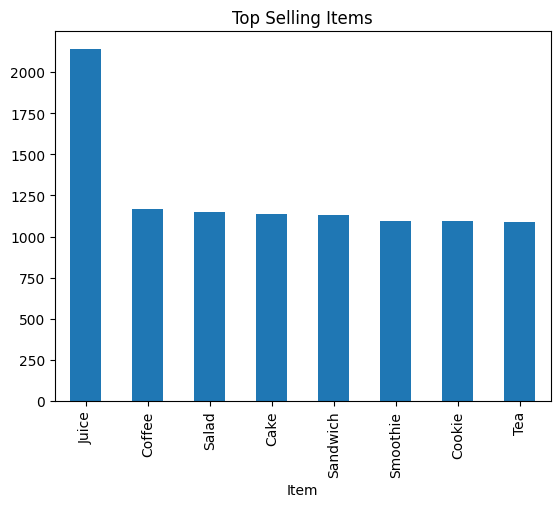

In [26]:
import matplotlib.pyplot as plt

df["Item"].value_counts().plot(kind="bar")
plt.title("Top Selling Items")
plt.show()

In [27]:
df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

Item
Juice       18972.0
Salad       17021.0
Sandwich    13484.0
Smoothie    13132.0
Cake        10341.0
Coffee       7184.0
Tea          5119.5
Cookie       3526.0
Name: Total Spent, dtype: float64

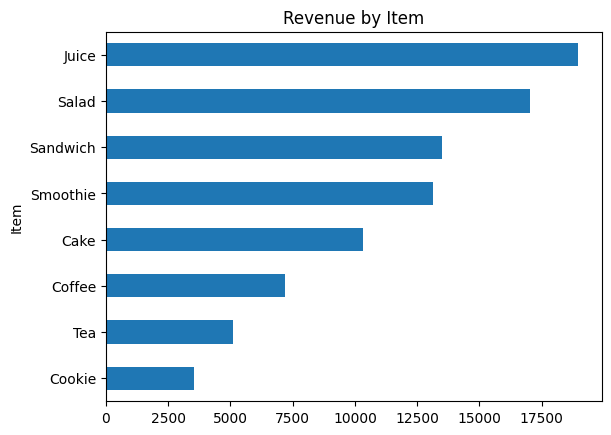

In [28]:
df.groupby("Item")["Total Spent"].sum().sort_values().plot(kind="barh")
plt.title("Revenue by Item")
plt.show()

In [29]:
df["Payment Method"].value_counts()

Payment Method
Digital Wallet    5469
Credit Card       2273
Cash              2258
Name: count, dtype: int64

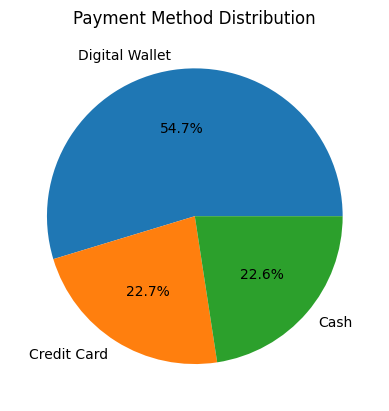

In [30]:
df["Payment Method"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Payment Method Distribution")
plt.show()

In [31]:
df["Location"].value_counts()

Location
Takeaway    6983
In-store    3017
Name: count, dtype: int64

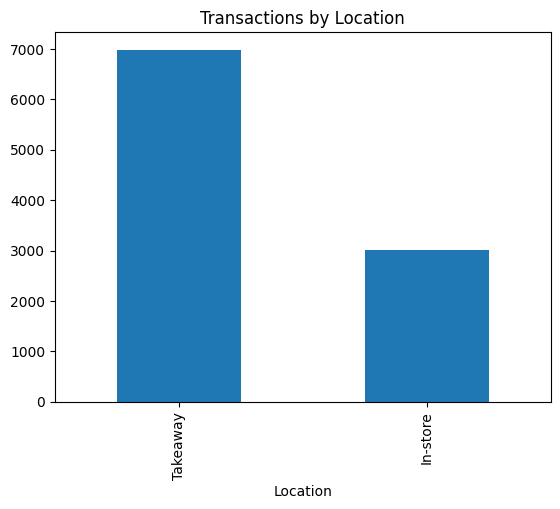

In [32]:
df["Location"].value_counts().plot(kind="bar")
plt.title("Transactions by Location")
plt.show()

In [33]:
df.groupby("Day_of_Week")["Total Spent"].sum()

Day_of_Week
Friday       12264.0
Monday       16332.5
Saturday     11976.0
Sunday       12246.5
Thursday     12362.5
Tuesday      11957.0
Wednesday    11641.0
Name: Total Spent, dtype: float64

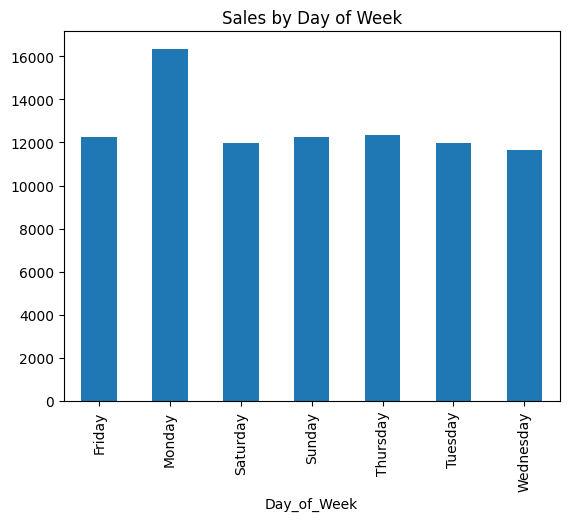

In [34]:
sales_day = df.groupby("Day_of_Week")["Total Spent"].sum()

sales_day.plot(kind="bar")
plt.title("Sales by Day of Week")
plt.show()

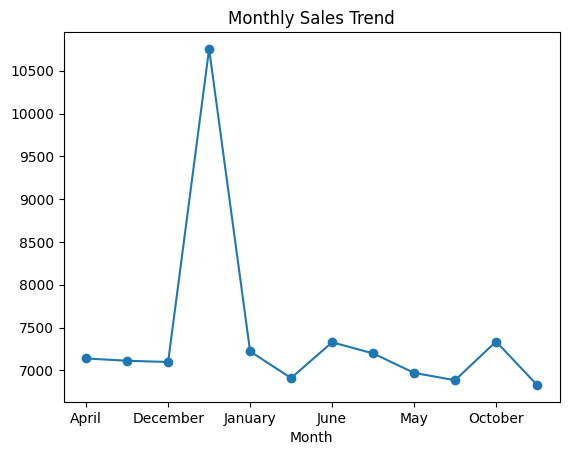

In [35]:
monthly_sales = df.groupby("Month")["Total Spent"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.show()